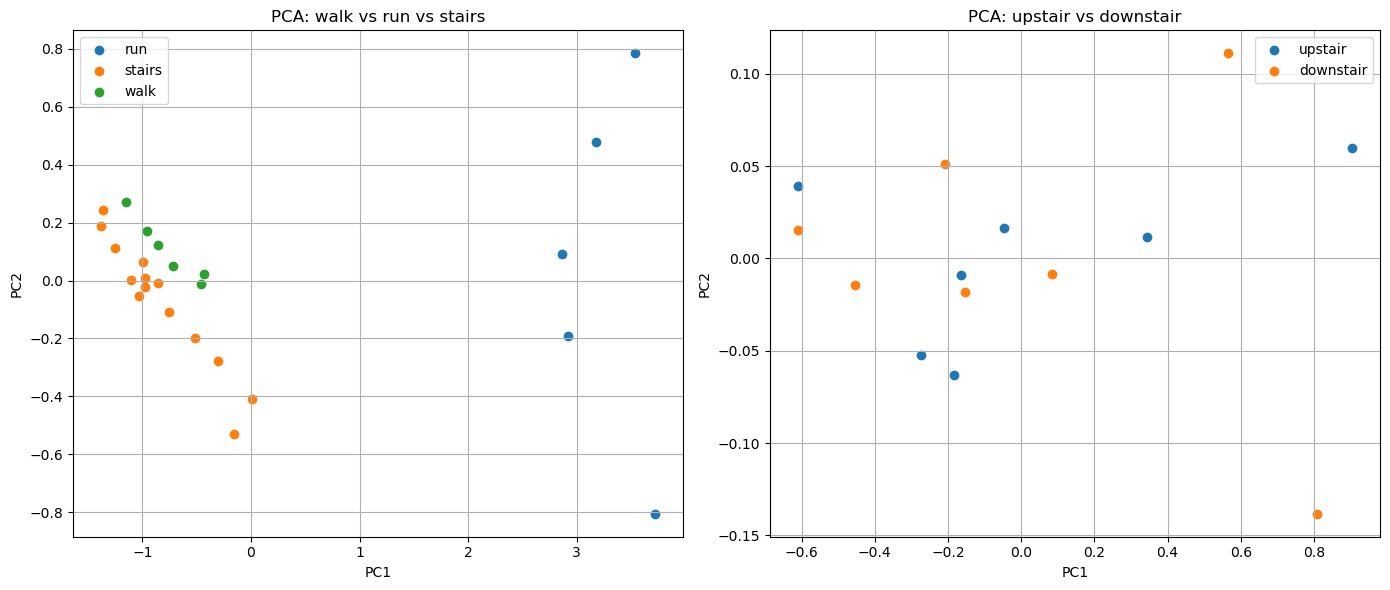

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt
import os
import glob
from sklearn.decomposition import PCA

def butter_lowpass_filter(data, cutoff, fs, order=4):
    nyq = 0.5 * fs
    normal_cutoff = cutoff / nyq
    b, a = butter(order, normal_cutoff, btype='low', analog=False)
    return filtfilt(b, a, data)

def mask_low_variation(signal, threshold=0.01):
    grad = np.abs(np.gradient(signal))
    mask = grad > threshold
    masked_signal = signal.copy()
    masked_signal[~mask] = np.nan
    return masked_signal

def process_filtered_signal(filename):
    df = pd.read_csv(os.path.join("data", filename))
    df['acc_total'] = np.sqrt(df['gFx']**2 + df['gFy']**2 + df['gFz']**2)

    # Extract time window from 10s to 15s
    start_time = df['time'].iloc[0] + 10
    end_time = start_time + 5
    df = df[(df['time'] >= start_time) & (df['time'] <= end_time)].reset_index(drop=True)

    # Estimate sampling frequency
    time_diff = np.diff(df['time'])
    fs = 1 / np.mean(time_diff) if len(time_diff) > 0 else 100

    # Apply filter and mask
    df['butter'] = butter_lowpass_filter(df['acc_total'], cutoff=5, fs=fs)
    df['butter_masked'] = mask_low_variation(df['butter'])

    return df['time'], df['butter_masked']

def load_combined_data():
    features = []
    labels = []
    for movement in ['run', 'walk', 'upstair', 'downstair']:
        files = glob.glob(f"data/{movement}*-ankle.csv")
        for file_path in files:
            filename = os.path.basename(file_path)
            try:
                time, masked_signal = process_filtered_signal(filename)
                clean_signal = masked_signal[~np.isnan(masked_signal)]
                if len(clean_signal) < 10:
                    continue

                feature_vector = [
                    np.nanmean(clean_signal),
                    np.nanstd(clean_signal),
                    np.nanmax(clean_signal) - np.nanmin(clean_signal),
                    np.nanmedian(clean_signal)
                ]
                features.append(feature_vector)

                if movement in ['upstair', 'downstair']:
                    labels.append('stairs')
                else:
                    labels.append(movement)
            except Exception as e:
                print(f"Error processing {filename}: {e}")
    return np.array(features), np.array(labels)

def load_up_vs_down_data():
    features = []
    labels = []
    for movement in ['upstair', 'downstair']:
        files = glob.glob(f"data/{movement}*-ankle.csv")
        for file_path in files:
            filename = os.path.basename(file_path)
            try:
                time, masked_signal = process_filtered_signal(filename)
                clean_signal = masked_signal[~np.isnan(masked_signal)]
                if len(clean_signal) < 10:
                    continue

                feature_vector = [
                    np.nanmean(clean_signal),
                    np.nanstd(clean_signal),
                    np.nanmax(clean_signal) - np.nanmin(clean_signal),
                    np.nanmedian(clean_signal)
                ]
                features.append(feature_vector)
                labels.append(movement)
            except Exception as e:
                print(f"Error processing {filename}: {e}")
    return np.array(features), np.array(labels)

def plot_two_pca_charts():
    X1, y1 = load_combined_data()
    X2, y2 = load_up_vs_down_data()

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    pca1 = PCA(n_components=2)
    X1_pca = pca1.fit_transform(X1)
    for label in np.unique(y1):
        idx = y1 == label
        axes[0].scatter(X1_pca[idx, 0], X1_pca[idx, 1], label=label)
    axes[0].set_title("PCA: walk vs run vs stairs")
    axes[0].set_xlabel("PC1")
    axes[0].set_ylabel("PC2")
    axes[0].legend()
    axes[0].grid(True)

    pca2 = PCA(n_components=2)
    X2_pca = pca2.fit_transform(X2)
    for label in ['upstair', 'downstair']:
        idx = y2 == label
        axes[1].scatter(X2_pca[idx, 0], X2_pca[idx, 1], label=label)
    axes[1].set_title("PCA: upstair vs downstair")
    axes[1].set_xlabel("PC1")
    axes[1].set_ylabel("PC2")
    axes[1].legend()
    axes[1].grid(True)

    plt.tight_layout()
    os.makedirs("plots", exist_ok=True)
    plt.savefig("plots/compare_pca.png")
    plt.show()

plot_two_pca_charts()
